In [52]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.sparse.linalg import splu, factorized
from scipy.linalg import lu_factor, lu_solve

### Q3 (d), (e)

In [59]:
def generate_randn_data(m,n):
    w = np.random.randn(n)
    x = np.maximum(w, 0)
    lambd = np.maximum(-w, 0)
    A = np.random.randn(m,n)
    nu = np.random.randn(m)
    b = A @ x
    
    # TODO: Find expression for c s.t. (x,nu,lambda) is optimal
    c = lambd - A.T@nu
    return A, b, c, x, lambd, nu


# TODO: write relevant arguments and compute F
def generate_F(A, b, c):
    m, n = A.shape
    F = np.concatenate([np.concatenate([A, np.zeros([m, m]), np.zeros([m, n])], axis=1), 
                        np.concatenate([np.zeros([n, n]), -A.T, np.eye(n)], axis=1), 
                        np.concatenate([c.reshape([len(c), 1]).T, b.reshape([len(b), 1]).T, np.zeros([1, n])], axis=1)], axis=0)
    return F


# TODO: write relevant arguments and compute g
def generate_g(b, c):
    g = np.concatenate([b, c, np.zeros(1)])
    return g

# TODO: write relevant arguments and compute the affine projection
def projection_affine(x, F, g, splu_factorized):
    dual_sol = splu_factorized.solve(F@x-g)
    proj_affine = x - F.T@dual_sol
    return proj_affine


# TODO: write relevant arguments and compute the non-negative orthant projection
def projection_positive(x, m, n):
    y = x.copy()
    y[:n] = np.maximum(y[:n], 0)
    y[n+m:] = np.maximum(y[n+m:], 0)
    return y

/var/folders/h6/k0hvphys1p5b28sdmwwfkh9r0000gn/T/ipykernel_48809/984915512.py:38: SparseEfficiencyWarning: splu converted its input to CSC format
  splu_factorized = splu(F@F.T) # or use the factorized method


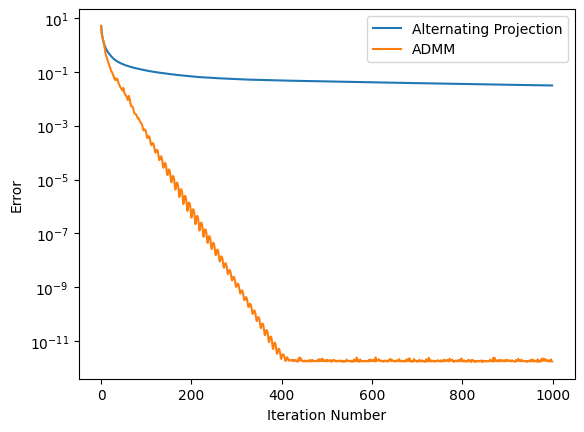

In [77]:
np.random.seed(42)

# TODO: write alternating projection
def alternating_projection(m, n, num_iters, F, g, splu_factorized):
    val1, rounds1 = [], []
    z = np.zeros(2*n+m)
    for i in range(num_iters):
        rounds1.append(i)
        z1 = projection_affine(z, F, g, splu_factorized)
        z = projection_positive(z1, m, n)
        error = np.linalg.norm(z1-z, 2)
        val1.append(error)
    return val1, rounds1
    

# TODO: write ADMM
def ADMM(m, n, num_iters, F, g, splu_factorized):
    val2, rounds2 = [], []
    z = np.zeros(2*n+m)
    u = np.zeros(2*n+m)
    for i in range(num_iters):
        rounds2.append(i)
        z1 = projection_affine(z-u, F, g, splu_factorized) # x
        z = projection_positive(z1+u, m, n) # z
        u = u + z1 - z
        error = np.linalg.norm(z1-z, 2)
        val2.append(error)
    return val2, rounds2

# main body
m = 100
n = 500
A, b, c, x_solution, lambd_solution, nu_solution = generate_randn_data(m,n)

# TODO: generate F and g and relevant factorization
F = generate_F(A, b, c)
g = generate_g(b, c)
splu_factorized = splu(F@F.T) # or use the factorized method

# run the two algorithms and plot the errors of the two algorithms over the iterations
num_iters = 1000
# Alternating projection
val1, rounds1 = alternating_projection(m, n, num_iters, F, g, splu_factorized)
plt.plot(rounds1, val1, label = "Alternating Projection")

# ADMM
val2, rounds2 = ADMM(m, n, num_iters, F, g, splu_factorized)
plt.plot(rounds2, val2, label = "ADMM")

plt.xlabel("Iteration Number")
plt.yscale("log")
plt.ylabel("Error")
plt.legend()
plt.show()